# 📊 Notebook 02: Extração de Dados COMPLETO

**Versão:** 2.0 - Implementação Completa  
**Data:** 2026-04-16

Este notebook contém a implementação COMPLETA da classe MasterExtractor.

---

In [1]:
"""Setup."""
import sys
from pathlib import Path
import logging
from typing import List, Optional

import pandas as pd
import numpy as np
import pdfplumber
from PyPDF2 import PdfReader
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(str(Path.cwd().parent / "src"))
from config import config

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

print("✅ Setup completo")

✅ Setup completo


In [2]:
"""Classe MasterExtractor COMPLETA."""

class MasterExtractor:
    """Extrator multimodal de dados ESG e financeiros."""
    
    def __init__(self, ticker: str, start_year: int, end_year: int):
        self.ticker = ticker
        self.start_year = start_year
        self.end_year = end_year
        self.logger = logging.getLogger(self.__class__.__name__)
    
    def _extract_text_from_pdf(self, file_path: Path) -> str:
        """Extrai texto de PDF com fallback."""
        text = []
        
        # Try pdfplumber first
        try:
            with pdfplumber.open(file_path) as pdf:
                for page in pdf.pages:
                    content = page.extract_text()
                    if content:
                        text.append(content)
            self.logger.debug(f"✅ pdfplumber: {file_path.name}")
            return "\n".join(text)
        except Exception as e:
            self.logger.warning(f"⚠️ pdfplumber falhou: {e}")
        
        # Fallback to PyPDF2
        try:
            reader = PdfReader(str(file_path))
            for page in reader.pages:
                t = page.extract_text()
                if t:
                    text.append(t)
            self.logger.debug(f"✅ PyPDF2: {file_path.name}")
            return "\n".join(text)
        except Exception as e:
            self.logger.error(f"❌ Ambos falharam: {e}")
            return ""
    
    def extract_esg_content(self, folder: Path) -> pd.DataFrame:
        """Processa todos os PDFs."""
        files = sorted(folder.glob("*.pdf"))
        self.logger.info(f"📂 {len(files)} PDFs encontrados")
        
        data = []
        for file in files:
            # Inferir ano
            digits = "".join(filter(str.isdigit, file.name))
            year = int(digits[:4]) if len(digits) >= 4 else None
            
            # Extrair texto
            text = self._extract_text_from_pdf(file)
            
            if text:
                data.append({
                    'year': year,
                    'filename': file.name,
                    'char_count': len(text),
                    'esg_disclosure_score': (
                        text.upper().count('ESG') + 
                        text.upper().count('SUSTAINABILITY')
                    )
                })
                self.logger.info(f"✅ {file.name} → {year}")
        
        return pd.DataFrame(data)
    
    def get_financial_data(self) -> pd.DataFrame:
        """Coleta dados via Yahoo Finance."""
        self.logger.info(f"📡 Yahoo Finance: {self.ticker}")
        
        try:
            ticker = yf.Ticker(self.ticker)
            hist = ticker.history(
                start=f"{self.start_year}-01-01",
                end=f"{self.end_year}-12-31"
            )
            
            if hist.empty:
                self.logger.error("❌ Sem dados financeiros")
                return pd.DataFrame()
            
            # Agregação anual
            annual = hist.resample('YE').agg({
                'Close': 'last',
                'Volume': 'mean'
            })
            
            annual['year'] = annual.index.year
            annual['annual_return_%'] = annual['Close'].pct_change() * 100
            
            annual = annual.rename(columns={
                'Close': 'close_price',
                'Volume': 'volume'
            })
            
            return annual.reset_index(drop=True)[[
                'year', 'close_price', 'volume', 'annual_return_%'
            ]]
        
        except Exception as e:
            self.logger.error(f"❌ API: {e}")
            raise
    
    def run(self) -> pd.DataFrame:
        """Pipeline completo."""
        self.logger.info("="*70)
        self.logger.info("🚀 INICIANDO EXTRAÇÃO")
        self.logger.info("="*70)
        
        # ESG
        df_esg = self.extract_esg_content(config.DATA_RAW)
        if df_esg.empty:
            self.logger.error("❌ Sem dados ESG")
            return None
        
        df_esg.to_csv(config.DATA_PROCESSED / "esg_raw.csv", index=False)
        
        # Financeiro
        df_fin = self.get_financial_data()
        if df_fin.empty:
            self.logger.error("❌ Sem dados financeiros")
            return None
        
        df_fin.to_csv(config.DATA_PROCESSED / "financial_data.csv", index=False)
        
        # Merge
        df_master = pd.merge(df_esg, df_fin, on='year', how='inner')
        df_master = df_master.drop(columns=['filename']).sort_values('year')
        
        # Salvar
        df_master.to_csv(config.DATA_PROCESSED / "esge_master.csv", index=False)
        
        self.logger.info("="*70)
        self.logger.info(f"✅ CONCLUÍDO: {df_master.shape}")
        self.logger.info("="*70)
        
        return df_master

print("✅ Classe MasterExtractor criada")

✅ Classe MasterExtractor criada


In [3]:
"""Executar extração."""

extractor = MasterExtractor(
    ticker="TECK-B.TO",
    start_year=2001,
    end_year=2025
)

df_master = extractor.run()

if df_master is not None:
    print("\n📋 Dataset Master:")
    print(df_master.head(10))
    print("\n📊 Estatísticas:")
    print(df_master.describe())
else:
    print("❌ Falha na extração")

2026-04-21 00:02:02 | INFO | MasterExtractor | ======================================================================
2026-04-21 00:02:02 | INFO | MasterExtractor | 🚀 INICIANDO EXTRAÇÃO
2026-04-21 00:02:02 | INFO | MasterExtractor | ======================================================================
2026-04-21 00:02:02 | INFO | MasterExtractor | 📂 25 PDFs encontrados
2026-04-21 00:02:15 | INFO | MasterExtractor | ✅ Teck_2001.pdf → 2001
2026-04-21 00:02:27 | INFO | MasterExtractor | ✅ Teck_2002.pdf → 2002
2026-04-21 00:02:47 | INFO | MasterExtractor | ✅ Teck_2003.pdf → 2003
2026-04-21 00:03:07 | INFO | MasterExtractor | ✅ Teck_2004.pdf → 2004
2026-04-21 00:03:44 | INFO | MasterExtractor | ✅ Teck_2005.pdf → 2005
2026-04-21 00:04:17 | INFO | MasterExtractor | ✅ Teck_2006.pdf → 2006
2026-04-21 00:05:12 | INFO | MasterExtractor | ✅ Teck_2007.pdf → 2007
2026-04-21 00:05:52 | INFO | MasterExtractor | ✅ Teck_2008.pdf → 2008
2026-04-21 00:07:03 | INFO | MasterExtractor | ✅ Teck_2009.pdf → 20

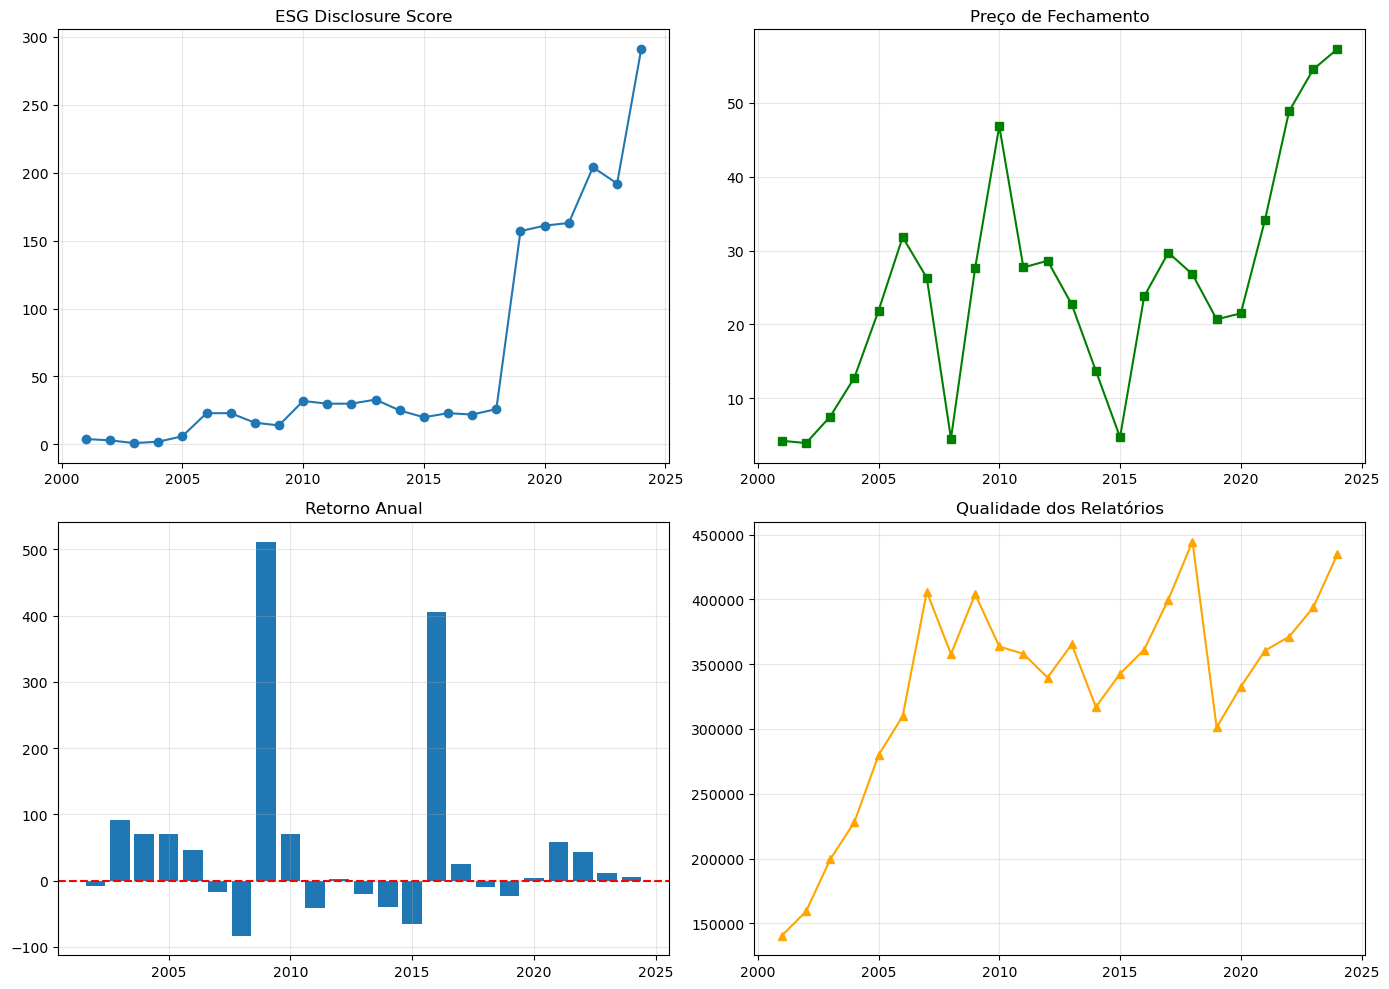

✅ Gráficos salvos


In [4]:
"""Visualizações exploratórias."""

if df_master is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # ESG Score
    axes[0,0].plot(df_master['year'], df_master['esg_disclosure_score'], marker='o')
    axes[0,0].set_title('ESG Disclosure Score')
    axes[0,0].grid(True, alpha=0.3)
    
    # Preço
    axes[0,1].plot(df_master['year'], df_master['close_price'], marker='s', color='green')
    axes[0,1].set_title('Preço de Fechamento')
    axes[0,1].grid(True, alpha=0.3)
    
    # Retorno
    axes[1,0].bar(df_master['year'], df_master['annual_return_%'])
    axes[1,0].axhline(0, color='red', linestyle='--')
    axes[1,0].set_title('Retorno Anual')
    axes[1,0].grid(True, alpha=0.3)
    
    # Qualidade
    axes[1,1].plot(df_master['year'], df_master['char_count'], marker='^', color='orange')
    axes[1,1].set_title('Qualidade dos Relatórios')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(config.OUTPUTS_FIGURES / "exploratory.png", dpi=300)
    plt.show()
    
    print("✅ Gráficos salvos")